# ARTI 403 – Image Processing — **Lab 1**
### Basics of Programming with Python

**Imam Abdulrahman Bin Faisal University** · College of Computer Science and Information Technology · Department of Computer Engineering

**Outcome #1:** Explain how digital images are represented and manipulated in a computer.

**Tools:** Python 3 · Anaconda · Jupyter / Spyder

This notebook completes Tasks 1–4 and the Assessment. Images used: `lena_gray_256.tif` (provided) and `cameraman.tif` (the classic *cameraman* image from scikit-image).

## Setup
Steps 1–4 of the manual (install Anaconda, start Jupyter/Spyder, install libraries) are one-time environment steps. Below we import the libraries the lab uses: **OpenCV**, **PIL/Pillow**, **NumPy**, **Matplotlib** (and **scikit-image** only to obtain `cameraman.tif`).

In [27]:
# One-time (run once if a package is missing), then restart the kernel:
# %pip install opencv-python scikit-image pillow matplotlib numpy

%matplotlib inline
import cv2                       # OpenCV
import numpy as np              # NumPy
import matplotlib.pyplot as plt # Matplotlib
import matplotlib.cm as cm
from PIL import Image           # Pillow (PIL)

print("OpenCV     :", cv2.__version__)
print("NumPy      :", np.__version__)
print("Pillow     :", Image.__version__)

OpenCV     : 5.0.0
NumPy      : 2.1.3
Pillow     : 11.1.0


In [28]:
# Make sure the two images sit inside an 'images/' folder next to this notebook.
# lena_gray_256.tif is provided with the lab.
# cameraman.tif is fetched once from scikit-image (skimage.data.camera()).
import os
os.makedirs('images', exist_ok=True)
if not os.path.exists('images/cameraman.tif'):
    from skimage import data, io
    io.imsave('images/cameraman.tif', data.camera())
print("Files in images/:", os.listdir('images'))

Files in images/: ['cameraman.tif', 'lena_gray_256.tif']


## Task #1 — Exercise with Spyder
Practice with the two cheat sheets (NumPy and Python Basics) from the Resources section. Below is a short warm-up covering the core Python/NumPy ideas the cheat sheets introduce.

In [29]:
# --- Python basics warm-up ---
name = "ARTI 403"
nums = [3, 1, 4, 1, 5, 9, 2, 6]
print("Course      :", name)
print("List        :", nums)
print("Sorted      :", sorted(nums))
print("Sum / Max   :", sum(nums), max(nums))
print("Even values :", [x for x in nums if x % 2 == 0])   # list comprehension

# --- NumPy basics warm-up ---
a = np.arange(1, 10).reshape(3, 3)   # 3x3 matrix 1..9
print("\nMatrix a:\n", a)
print("Shape:", a.shape, "| Sum:", a.sum(), "| Column means:", a.mean(axis=0))
print("a * 2:\n", a * 2)
print("Transpose:\n", a.T)

Course      : ARTI 403
List        : [3, 1, 4, 1, 5, 9, 2, 6]
Sorted      : [1, 1, 2, 3, 4, 5, 6, 9]
Sum / Max   : 31 9
Even values : [4, 2, 6]

Matrix a:
 [[1 2 3]
 [4 5 6]
 [7 8 9]]
Shape: (3, 3) | Sum: 45 | Column means: [4. 5. 6.]
a * 2:
 [[ 2  4  6]
 [ 8 10 12]
 [14 16 18]]
Transpose:
 [[1 4 7]
 [2 5 8]
 [3 6 9]]


## Task #2 — Loading and Visualizing Images

**a) Loading/reading an image using OpenCV** — `cv2.imread` returns the pixel data as a NumPy array.

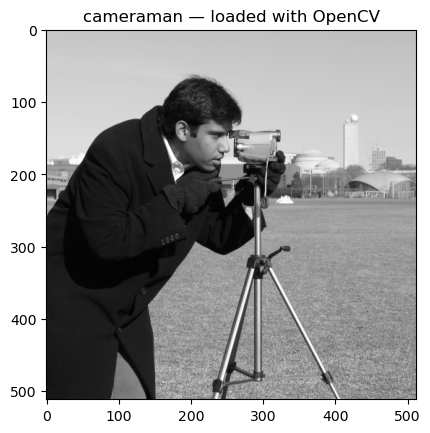

In [30]:
img = cv2.imread('images/cameraman.tif')  # load the image data into a NumPy array
plt.imshow(img)
plt.title('cameraman — loaded with OpenCV')
plt.show()

> **Note on colours:** OpenCV reads pixels in **BGR** order, while Matplotlib expects **RGB**. For a grayscale source loaded as 3 channels this only tints the display. To show it faithfully, convert with `cv2.cvtColor(img, cv2.COLOR_BGR2RGB)` or load as a single channel with `cv2.imread(path, cv2.IMREAD_GRAYSCALE)`.

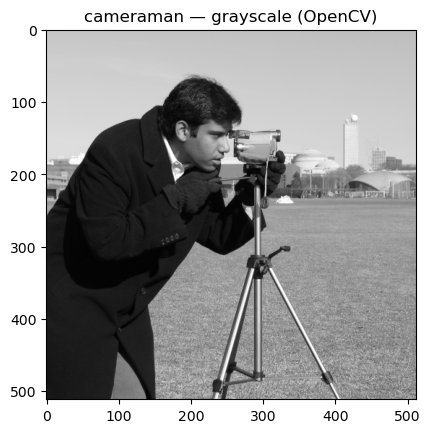

In [31]:
# Faithful grayscale display of the same image
gray = cv2.imread('images/cameraman.tif', cv2.IMREAD_GRAYSCALE)
plt.imshow(gray, cmap='gray')
plt.title('cameraman — grayscale (OpenCV)')
plt.show()

**b) Loading/reading an image using PIL** — `Image.open` returns a PIL image object; we display it with a grayscale colormap.

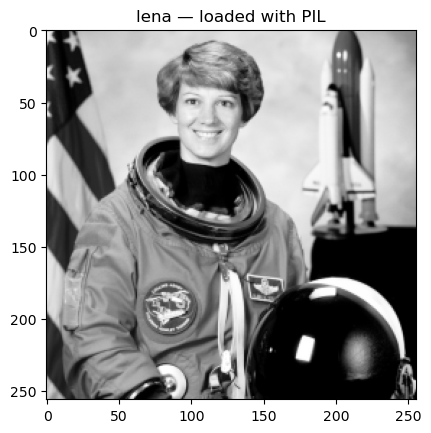

PIL image  ->  mode: L | size (W x H): (256, 256)


In [32]:
img2 = Image.open('images/lena_gray_256.tif')  # load image into a PIL Image object
plt.imshow(img2, cmap=cm.Greys_r)
plt.title('lena — loaded with PIL')
plt.show()
print("PIL image  ->  mode:", img2.mode, "| size (W x H):", img2.size)

## Task #3 — Image Storing
Save images back to disk. OpenCV uses `cv2.imwrite`; PIL uses the image object's `.save` method. The file extension decides the format (here JPEG).

In [33]:
ok = cv2.imwrite('new_image.jpg', img)   # OpenCV save
img2.save('new_image2.jpg')              # PIL save

import os
print("OpenCV  -> new_image.jpg  saved:", ok,  "|", os.path.getsize('new_image.jpg'),  "bytes")
print("PIL     -> new_image2.jpg saved:", True, "|", os.path.getsize('new_image2.jpg'), "bytes")

OpenCV  -> new_image.jpg  saved: True | 86612 bytes
PIL     -> new_image2.jpg saved: True | 11989 bytes


## Task #4 — Display Image as an Array
A digital image **is** a NumPy array of pixel values. `.shape` gives its dimensions; printing the array shows the intensity of every pixel (0 = black … 255 = white for 8-bit images).

In [34]:
# The OpenCV image is already a NumPy array
print("img.shape (OpenCV / cameraman):", img.shape)   # (rows, cols, channels)
print("Top-left 8x8 block (one channel):")
print(img[:8, :8, 0])
print(img)
print(img_array)

img.shape (OpenCV / cameraman): (512, 512, 3)
Top-left 8x8 block (one channel):
[[200 200 200 200 199 200 199 198]
 [200 199 199 200 199 200 199 198]
 [199 199 199 200 200 200 200 200]
 [200 200 199 199 199 199 199 199]
 [200 200 200 200 199 199 199 200]
 [200 199 199 200 199 199 199 199]
 [200 201 200 200 199 200 198 199]
 [201 200 200 200 200 199 199 200]]
[[[200 200 200]
  [200 200 200]
  [200 200 200]
  ...
  [189 189 189]
  [190 190 190]
  [190 190 190]]

 [[200 200 200]
  [199 199 199]
  [199 199 199]
  ...
  [190 190 190]
  [190 190 190]
  [190 190 190]]

 [[199 199 199]
  [199 199 199]
  [199 199 199]
  ...
  [190 190 190]
  [190 190 190]
  [190 190 190]]

 ...

 [[ 25  25  25]
  [ 25  25  25]
  [ 27  27  27]
  ...
  [139 139 139]
  [122 122 122]
  [147 147 147]]

 [[ 25  25  25]
  [ 25  25  25]
  [ 26  26  26]
  ...
  [158 158 158]
  [141 141 141]
  [168 168 168]]

 [[ 25  25  25]
  [ 25  25  25]
  [ 27  27  27]
  ...
  [151 151 151]
  [152 152 152]
  [149 149 149]]]
[[141  93

In [35]:
# Convert the PIL image to a NumPy array
img_array = np.array(img2)
print("img_array.shape (PIL / lena):", img_array.shape, "| dtype:", img_array.dtype)
print("Top-left 8x8 block:")
print(img_array[:8, :8])

img_array.shape (PIL / lena): (256, 256) | dtype: uint8
Top-left 8x8 block:
[[141  93 117 147 149 104  33   4]
 [196 177 183 189 160  84  17   5]
 [225 217 210 190 132  48  13   6]
 [228 223 208 168  90  31  15   6]
 [223 218 204 163  83  33  17   7]
 [222 219 208 183 131  60  19   8]
 [223 220 211 199 170 113  41   9]
 [217 201 180 179 174 145  88  21]]


## Assessment — NumPy Operations on the Image Array
*"The student will be asked to perform different operations on the array using the NumPy library."* Below are the common operations used throughout image processing, applied to the Lena array.

In [36]:
# 1) Inspect the array
print("shape:", img_array.shape, "| ndim:", img_array.ndim, "| size:", img_array.size, "pixels")
print("dtype:", img_array.dtype)

# 2) Statistics
print("\nmin :", img_array.min(), " max:", img_array.max())
print("mean: %.2f   std: %.2f" % (img_array.mean(), img_array.std()))

# 3) Indexing & slicing
print("\npixel (0,0)      :", img_array[0, 0])
print("pixel (100,100)  :", img_array[100, 100])
print("first row (first 10 values):", img_array[0, :10])

shape: (256, 256) | ndim: 2 | size: 65536 pixels
dtype: uint8

min : 0  max: 254
mean: 112.25   std: 74.29

pixel (0,0)      : 141
pixel (100,100)  : 9
first row (first 10 values): [141  93 117 147 149 104  33   4   1   3]


In [37]:
# 4) Element-wise operations to produce new images
negative   = 255 - img_array                                         # photographic negative
brighter   = np.clip(img_array.astype(int) + 50, 0, 255).astype(np.uint8)  # +50 brightness (clipped)
threshold  = np.where(img_array > 128, 255, 0).astype(np.uint8)      # binary threshold at 128

# 5) Geometric operations
crop       = img_array[64:192, 64:192]   # center 128x128 crop
flip_lr    = np.fliplr(img_array)        # mirror left-right
flip_ud    = np.flipud(img_array)        # flip upside-down
transpose  = img_array.T                 # transpose (rows <-> cols)

for nm, arr in [("negative", negative), ("brighter", brighter), ("threshold", threshold),
                ("crop", crop), ("flip_lr", flip_lr), ("flip_ud", flip_ud), ("transpose", transpose)]:
    print(f"{nm:10s} -> shape={arr.shape}, min={arr.min()}, max={arr.max()}")

negative   -> shape=(256, 256), min=1, max=255
brighter   -> shape=(256, 256), min=50, max=255
threshold  -> shape=(256, 256), min=0, max=255
crop       -> shape=(128, 128), min=0, max=254
flip_lr    -> shape=(256, 256), min=0, max=254
flip_ud    -> shape=(256, 256), min=0, max=254
transpose  -> shape=(256, 256), min=0, max=254


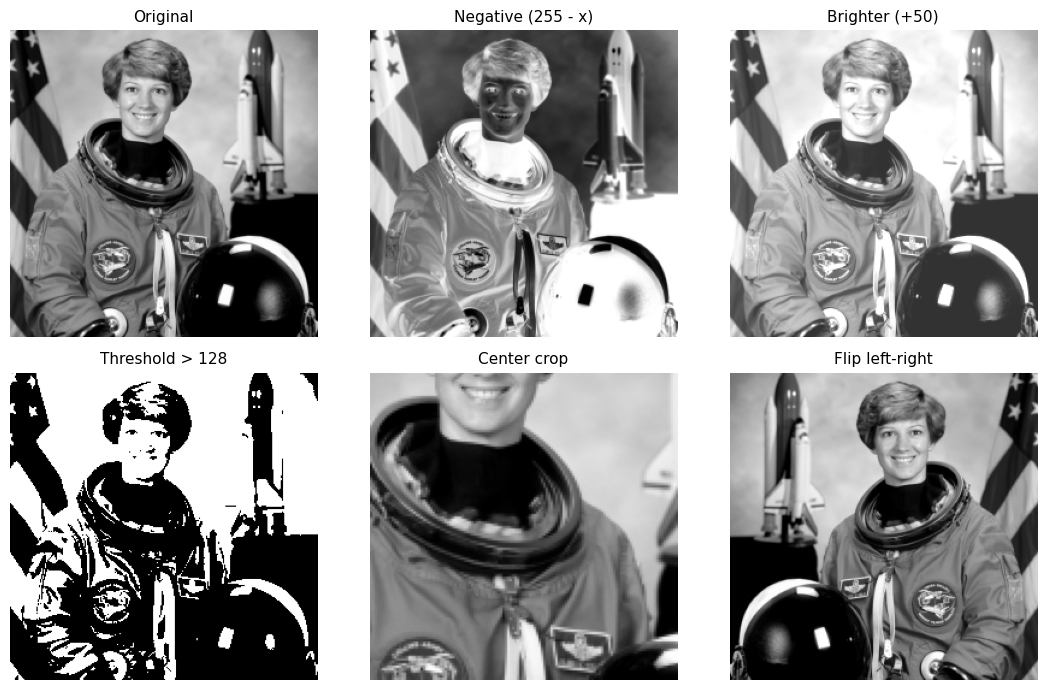

In [38]:
# 6) Visualize the results
tiles = [("Original", img_array), ("Negative (255 - x)", negative),
         ("Brighter (+50)", brighter), ("Threshold > 128", threshold),
         ("Center crop", crop), ("Flip left-right", flip_lr)]

fig, axes = plt.subplots(2, 3, figsize=(11, 7))
for ax, (title, im) in zip(axes.ravel(), tiles):
    ax.imshow(im, cmap='gray', vmin=0, vmax=255)
    ax.set_title(title, fontsize=11)
    ax.axis('off')
plt.tight_layout()
plt.show()

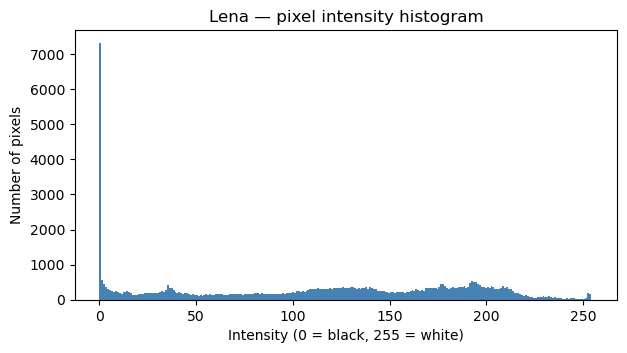

In [39]:
# 7) Histogram of pixel intensities — how brightness is distributed across the image
plt.figure(figsize=(7, 3.5))
plt.hist(img_array.ravel(), bins=256, range=(0, 255), color='steelblue')
plt.title('Lena — pixel intensity histogram')
plt.xlabel('Intensity (0 = black, 255 = white)')
plt.ylabel('Number of pixels')
plt.show()

### Summary
- **Task 1:** Practiced core Python and NumPy operations.
- **Task 2:** Loaded images with **OpenCV** (`cv2.imread` → NumPy array) and **PIL** (`Image.open` → image object), and displayed them.
- **Task 3:** Saved images to disk with `cv2.imwrite` and `PIL.Image.save`.
- **Task 4:** Showed that an image is a NumPy array via `.shape` and by printing pixel values.
- **Assessment:** Applied NumPy operations — statistics, indexing/slicing, negative, brightness, thresholding, cropping, flipping, transpose, and a histogram — demonstrating how digital images are represented and manipulated in a computer (**Outcome #1**).